<a href="https://colab.research.google.com/github/so-alive/ML---Mental-Health-Score/blob/main/ML_Mental_Health_Score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [103]:
# importing libraries as per our need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset - Check Shape, Column Names


In [104]:
# Load Dataset
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [105]:
# total rows and columns
df.shape

(5000, 13)

In [106]:
# Look at first 5 rows
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


# Dataset understanding - data types, missing values, duplicate rows

In [107]:
# Check if the dataset is clean (contains NULL or not)
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [108]:
# Check for duplicates
df.duplicated().sum()

np.int64(2)

In [109]:
# Check types of Data columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [110]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


# Exploratory Data Analysis

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

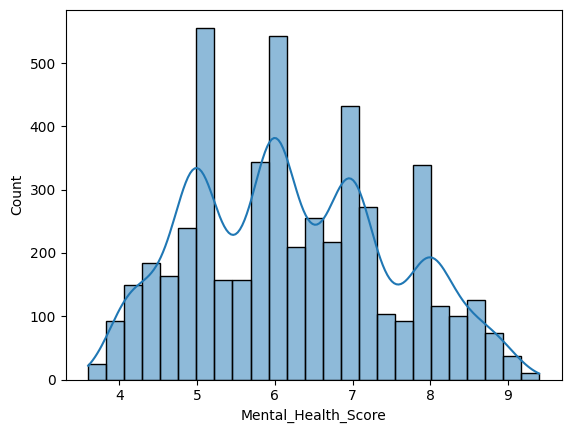

In [111]:
# shape of target column (centralized, left skewed, right skewed)
sns.histplot(df['Mental_Health_Score'], kde=True)
# kde -> Kernel Density Estimation (this function overlays a smooth, continuous curve)

<Axes: >

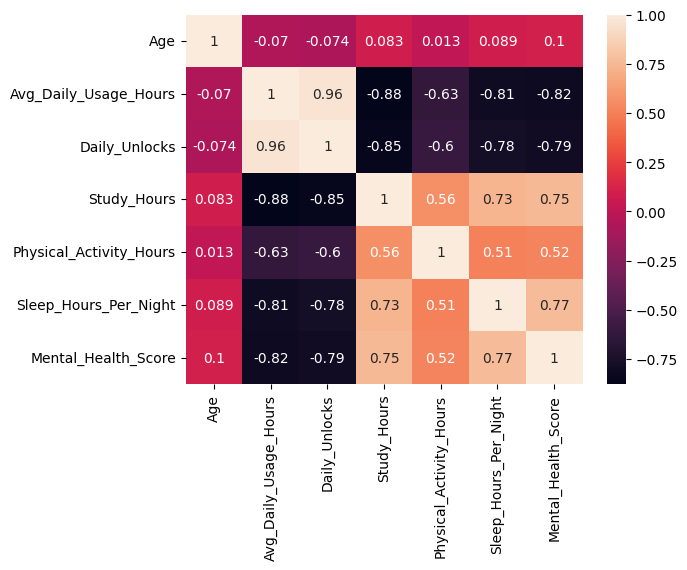

In [112]:
# creates a heatmap (numeric features only)
# +ve corr directly proportional (ek column ki value increase krne pr dusra bhi increase ho. (^_^ then ^_^))
# -ve corr inversely proportional (ek column ki value increase krne pr dusra decrease hone lge. (^_^ then ＞﹏＜))
# annot = true (assigns numeric value)
sns.heatmap(df.corr(numeric_only = True), annot=True)

In [113]:
# Stress Level vs Mental Health Score
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

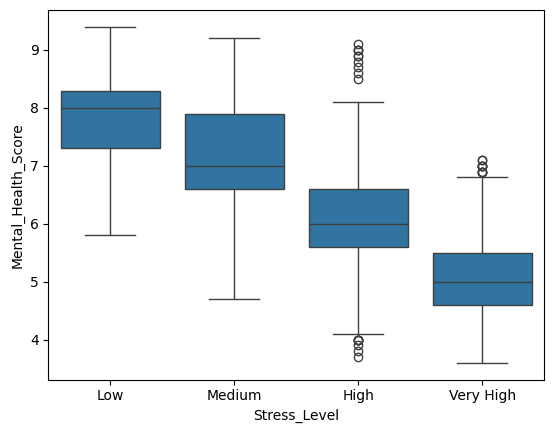

In [114]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score', data=df, order= order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

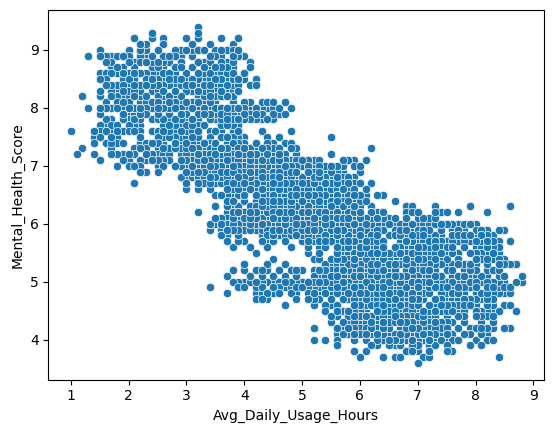

In [115]:
# Daily Usage Hours VS Mental Health Score
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data = df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

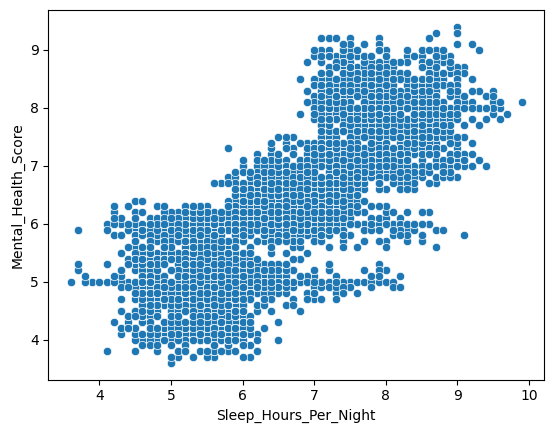

In [116]:
# Sleep Hours VS Mental Health Score
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score', data=df)

<Axes: xlabel='Physical_Activity_Hours', ylabel='Mental_Health_Score'>

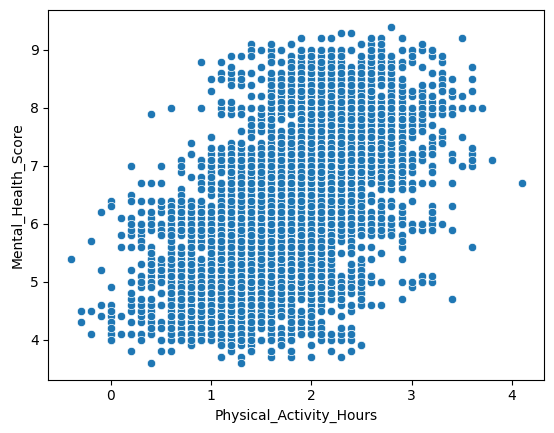

In [117]:
# Physical Activity VS Mental Health Score
sns.scatterplot(x='Physical_Activity_Hours', y='Mental_Health_Score', data=df)

<Axes: xlabel='Study_Hours', ylabel='Mental_Health_Score'>

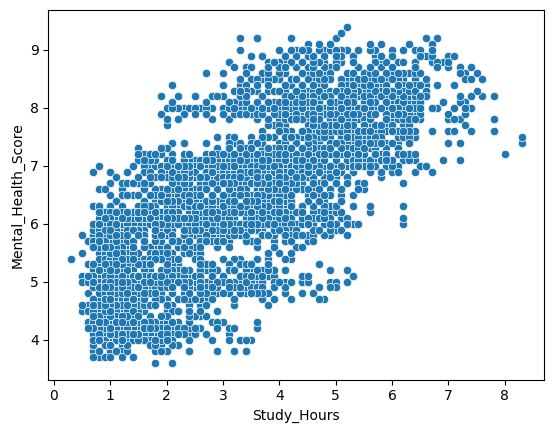

In [118]:
# Study Hours VS Mental Health Score
sns.scatterplot(x='Study_Hours', y='Mental_Health_Score', data=df)

In [119]:
# Most Used Plaform countplot
df['Most_Used_Platform'].value_counts()

,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


<Axes: xlabel='Most_Used_Platform', ylabel='count'>

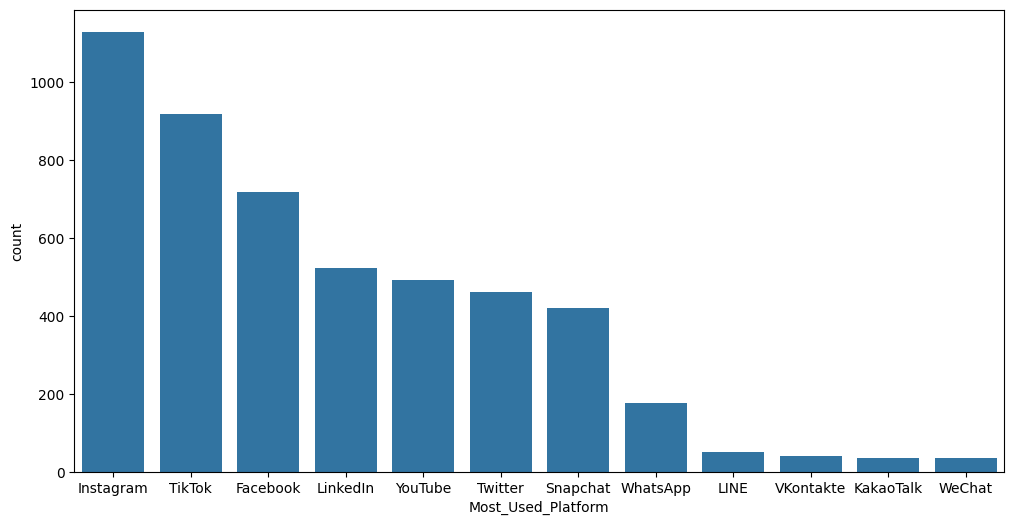

In [120]:
plt.figure(figsize=(12,6))
sns.countplot(x = df['Most_Used_Platform'], order = df['Most_Used_Platform'].value_counts().index)

In [121]:
# Checking Outliers (above upperbound or below lowerbound are outliers)
num_features = df.select_dtypes(include= 'number')
Q1 = num_features.quantile(0.25)
Q3 =num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


# Data Cleaning

In [122]:
#1. To drop duplicates
df = df.drop_duplicates()

#2. Converting Negative value or Unrealistic value to Realistic
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

# Skewness

In [123]:
# near zero centralized
# -ve (left skewed)
# +ve (right skewed)
num_cols = df.select_dtypes(include='number')
num_cols.skew()

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


# Feature Engineering

In [124]:
# we had 111 countries in our data
# it would have been hard to manage
# so, we went from 111 raw categories down to 11 manageable ones
top_countries = df['Country'].value_counts().index[:10].tolist()

In [125]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'


In [126]:
df['Grouped_country'] = df['Country'].apply(group_countries)

In [127]:
df['Grouped_country'].value_counts()

,count
Grouped_country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


# Train-Test Split

In [128]:
from sklearn.model_selection import train_test_split

skewed_col         = ['Study_Hours']
other_numeric_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
                      'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
ordinal_col        = ['Stress_Level']
normal_cols        = ['Gender', 'Academic_Level', 'Most_Used_Platform',
                      'Purpose_Of_Use', 'Grouped_country']


feature_col = skewed_col + other_numeric_cols + ordinal_col + normal_cols
X = df[feature_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Preprocessing using ColumnTransformer

In [129]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer


#1. Skewed Features
skew_pipeline = Pipeline(steps =[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

#2. Numeric Features
plain_numeric_pipeline = Pipeline(steps = [
    ('scale', StandardScaler())
])

#3. Ordinal Features
ordinal_pipeline = Pipeline(steps = [
    ('encode', OrdinalEncoder(categories = [['Low', 'Medium', 'High', 'Very High']]))
])

#4. Nominal Features
nominal_pipeline = Pipeline(steps = [
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

# konsi pipeline, konsa feature
preprocessor = ColumnTransformer(transformers= [
    ("Skewed_Pipeline", skew_pipeline, skewed_col),
    ("Plain_Numeric", plain_numeric_pipeline, other_numeric_cols),
    ("Ordinal", ordinal_pipeline, ordinal_col),
    ("Nominal", nominal_pipeline, normal_cols)
])



# Model Building

In [130]:
# Baseline: Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds       = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

lr_r2_testing  = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae         = mean_absolute_error(y_test, lr_preds)

print(f'Accuracy of Training {lr_r2_training}')
print(f'Accuracy of Testing {lr_r2_testing}')
print(f'MAE {lr_mae}')

Accuracy of Training 0.7236771199387538
Accuracy of Testing 0.7397944617433021
MAE 0.5361775634720181


In [131]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor


rf_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds       = rf_pipeline.predict(X_test)
rf_preds_train = rf_pipeline.predict(X_train)

rf_r2_testing  = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_train)
rf_mae         = mean_absolute_error(y_test, rf_preds)

print(f'Accuracy of Training {rf_r2_training}')
print(f'Accuracy of Testing {rf_r2_testing}')
print(f'Mae {rf_mae}')

Accuracy of Training 0.9808287942404612
Accuracy of Testing 0.8775888638668996
Mae 0.34722113333333343


# Hyperparameter tuning the Random Forest

In [132]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random forest__n_estimators'      : [100, 200, 300],
    'random forest__max_depth'         : [5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf'  : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator = rf_pipeline,
    param_distributions= param_grid,
    n_iter = 15,
    cv = 5,
    scoring = 'r2',
    random_state = 42,
    n_jobs = -1
)

random_search.fit(X_train, y_train)


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Plain_Numeric',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks',
                                                                                'Ph...
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_country'])])),
                                             ('random forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random forest__max_depth': [5, 10, 15],
                                        'random forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, scoring='r2')

In [133]:
random_search.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [134]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds = rf_best_pipeline.predict(X_test)

print (f'R2 score for Random Forest after Hyperparameter tuning {r2_score(y_test, rf_best_preds)}')
print (f'MAE Score for Random Forest after Hyperparameter tuning {mean_absolute_error(y_test, rf_best_preds)}')

R2 score for Random Forest after Hyperparameter tuning 0.8650140569761653
MAE Score for Random Forest after Hyperparameter tuning 0.3689015766630922


# Model Evaluation

In [135]:
from sklearn.metrics import mean_squared_error

# Calculate Root Mean Square Error (RMSE) for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
rf_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a  DataFrame to consolidate results
results = pd.DataFrame({
    'Model' : ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2' : [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2' : [lr_r2_training, rf_r2_training, rf_tuned_training],
    'MAE' : [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE' : [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)

                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.739794     0.723677  0.536178  0.676032
1  Random Forest (default)  0.877589     0.980829  0.347221  0.463681
2    Random Forest (tuned)  0.865014     0.954703  0.368902  0.486915


# Save the Model

In [136]:
import joblib
joblib.dump(rf_pipeline, 'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']